In [35]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [36]:
df = pd.read_csv("Churn_Modelling.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


# Data Cleaning

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [38]:
# Missing value
df.isna().sum().sum()

np.int64(0)

In [39]:
# Duplicate values
df.duplicated().sum()

np.int64(0)

In [40]:
# spelling error
col = []
for i in df.columns:
    if df[i].dtypes in ['Category','object','str']:
        pass
        # print(f"{i} : {df[i].unique().tolist()}\n")
        # print(df[i].value_counts())

In [41]:
# Data Types is ok but if Datetime then check twice

In [42]:
# Checking the inconsistent formatting - spaces,case
df['Gender'] != df['Gender'].str.strip()   # where True that means space, masking and see the rows

# repr() clearly shows the spaces.
# Sometimes spaces are invisible.
for value in df['Gender'].unique():
    print(repr(value))

# Fix extra spaces 
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

'Female'
'Male'


In [43]:
# checking range and invalid values

# check for single column
valid_gender = ['Male','Female']
df[~df['Gender'].isin(valid_gender)]

# Best to set your own rule and check
rules = {
    'Age': (0,120),
    'IsActiveMember': (0,1),
    'NumOfProducts': (0,100)
}

for col,(low,high) in rules.items():
    invalid = df[~df[col].between(low,high)]
    print(f"{col}: {len(invalid)} invalid values")

Age: 0 invalid values
IsActiveMember: 0 invalid values
NumOfProducts: 0 invalid values


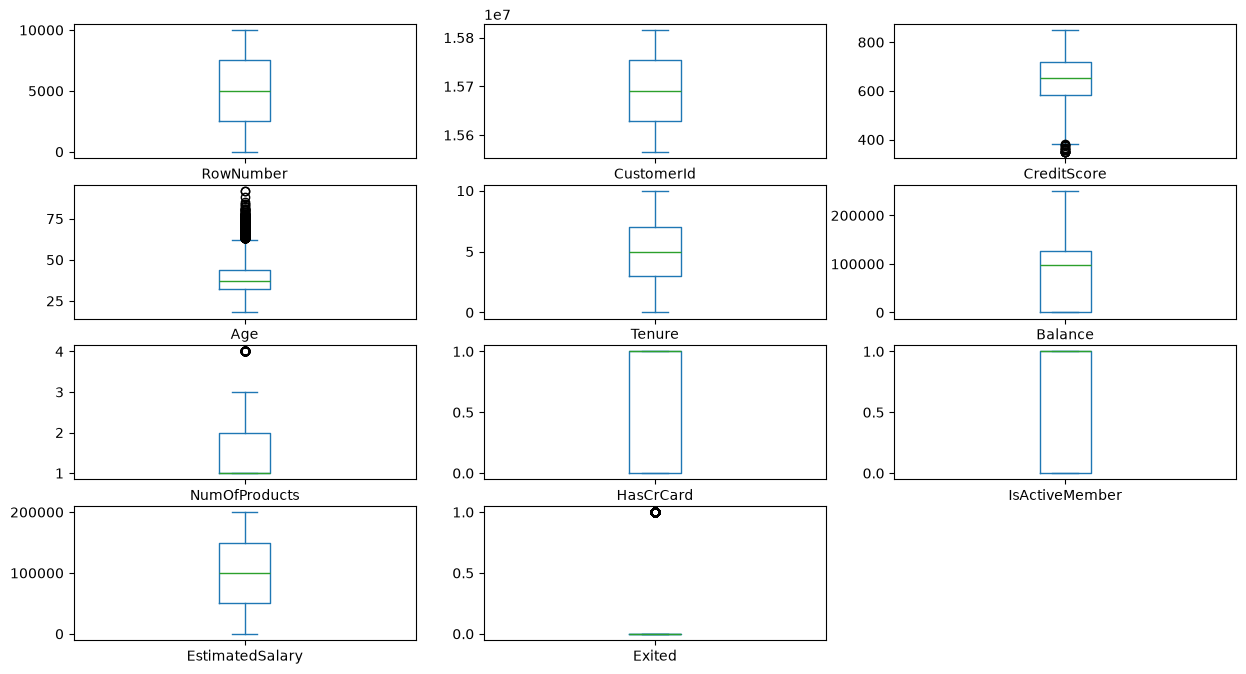

In [44]:
# Checking outliers
df.select_dtypes(include='number').plot(
    kind='box',
    subplots=True,
    layout = (-1,3),
    figsize=(15,8)
)
plt.show()

In [45]:
# check actual outliers
def detect_out(n):
    data = df.select_dtypes(include='number')

    for i in data:
        data=df[i].dropna()
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = data[(data < lower) | (data > upper)]

        print("\ncolumn", i)
        print("no_outlier :", len(outliers))
        
        if len(outliers)>0:
            print(outliers)
detect_out('Age')


column RowNumber
no_outlier : 0

column CustomerId
no_outlier : 0

column CreditScore
no_outlier : 15
7       376
942     376
1193    363
1405    359
1631    350
1838    350
1962    358
2473    351
2579    365
8154    367
8723    350
8762    350
9210    382
9356    373
9624    350
Name: CreditScore, dtype: int64

column Age
no_outlier : 359
58      66
85      75
104     65
158     73
181     65
        ..
9753    68
9765    64
9832    64
9894    77
9936    77
Name: Age, Length: 359, dtype: int64

column Tenure
no_outlier : 0

column Balance
no_outlier : 0

column NumOfProducts
no_outlier : 60
7       4
70      4
1254    4
1469    4
1488    4
1701    4
1876    4
2124    4
2196    4
2285    4
2462    4
2499    4
2509    4
2541    4
2614    4
2617    4
2872    4
3152    4
3365    4
3841    4
4013    4
4014    4
4166    4
4260    4
4403    4
4511    4
4516    4
4606    4
4654    4
4748    4
4822    4
5010    4
5137    4
5235    4
5386    4
5700    4
5904    4
6150    4
6172    4
6279    4

In [46]:
# Exited column is imbalanced so unchanged 
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

# Univariate Analysis

[Text(0, 0, '5014'), Text(0, 0, '2477'), Text(0, 0, '2509')]

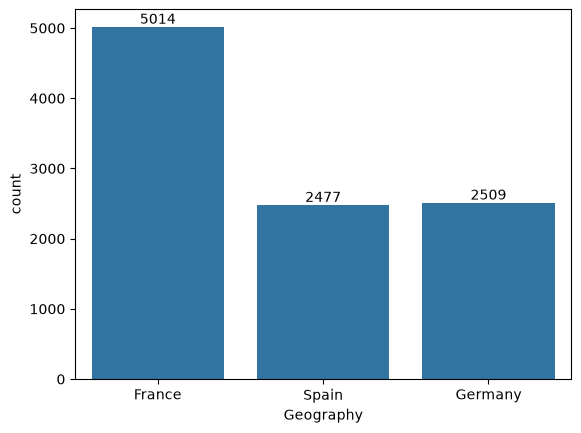

In [47]:
ax=sns.countplot(x=df['Geography'])
ax.bar_label(ax.containers[0] )

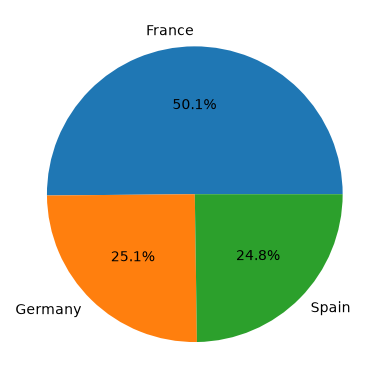

In [48]:
plt.pie(df['Geography'].value_counts(),
        labels=df['Geography'].value_counts().index,
        autopct='%1.1f%%')
plt.show()

[Text(0, 0, '4543'), Text(0, 0, '5457')]

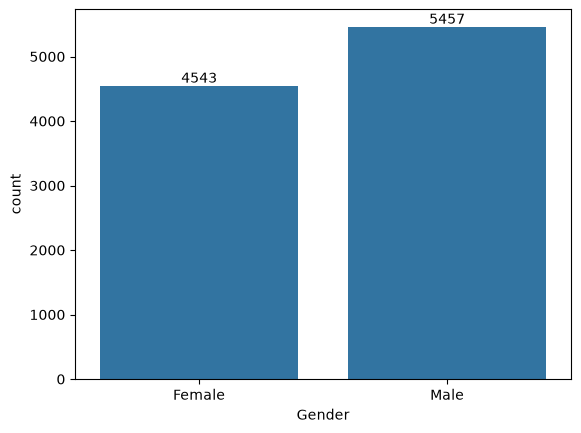

In [49]:
ax=sns.countplot(x=df['Gender'])
ax.bar_label(ax.containers[0] )

[Text(0, 0, '32'),
 Text(0, 0, '29'),
 Text(0, 0, '29'),
 Text(0, 0, '28'),
 Text(0, 0, '26'),
 Text(0, 0, '25'),
 Text(0, 0, '25'),
 Text(0, 0, '25'),
 Text(0, 0, '24'),
 Text(0, 0, '24')]

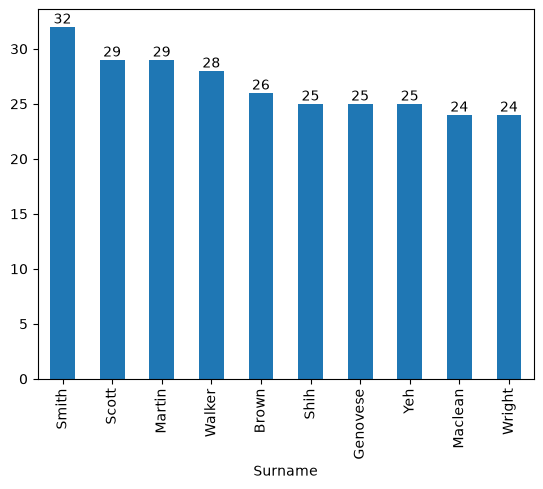

In [50]:
# not required visualiztion bcz of many value onlu find unique,counts etc..
ax=df['Surname'].value_counts().head(10).plot(kind='bar')
ax.bar_label(ax.containers[0] )

<Axes: ylabel='Frequency'>

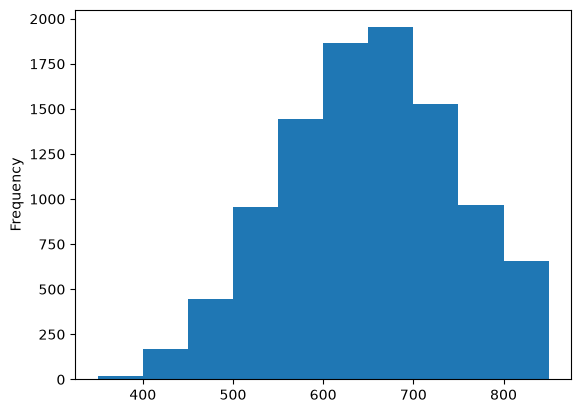

In [51]:
df['CreditScore'].plot(kind='hist')

In [52]:
df['CreditScore'].median()

np.float64(652.0)

In [53]:
df['CreditScore'].skew()

np.float64(-0.07160660820092675)

<Axes: xlabel='CreditScore'>

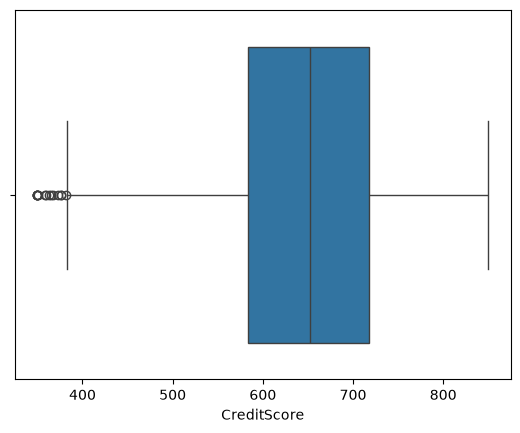

In [54]:
sns.boxplot(x=df['CreditScore'])

<Axes: xlabel='Age', ylabel='Count'>

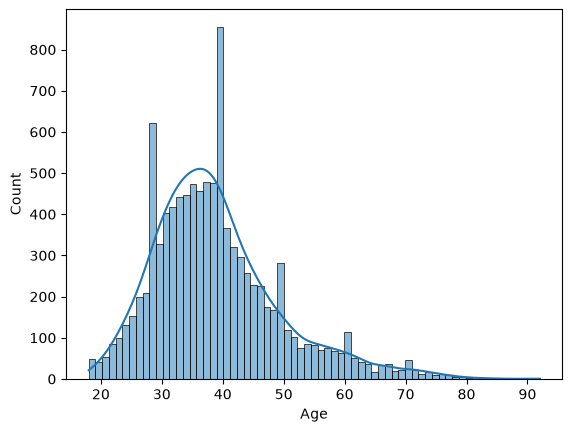

In [55]:
sns.histplot(df['Age'],kde=True)

In [56]:
df['Age'].skew()

np.float64(1.0113202630234552)

<Axes: xlabel='Age'>

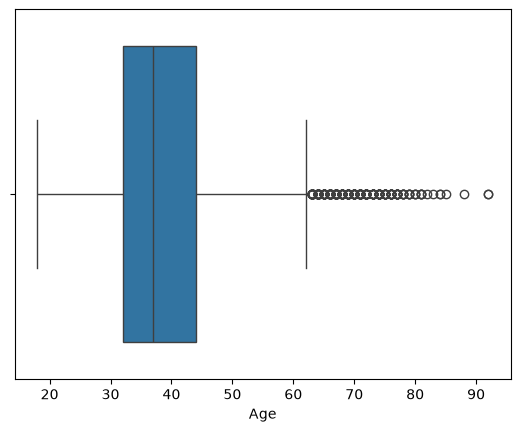

In [57]:
sns.boxplot(x=df['Age'])

In [58]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


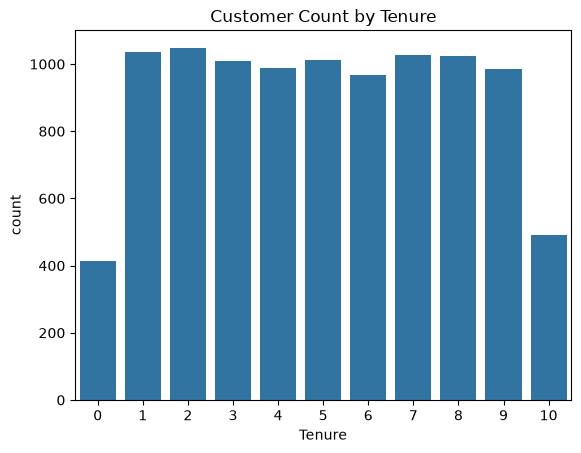

In [59]:
sns.countplot(x='Tenure', data=df)
plt.title("Customer Count by Tenure")
plt.show()

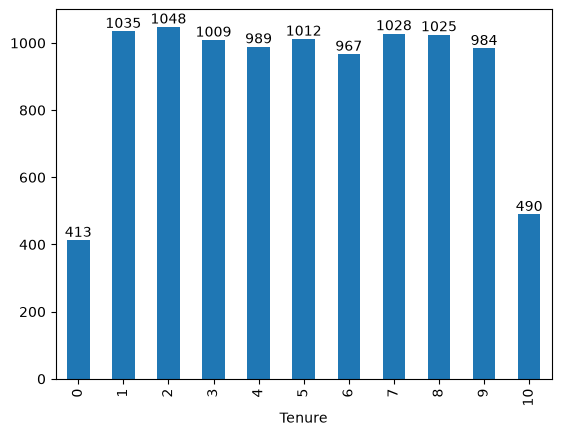

In [60]:
ax=df['Tenure'].value_counts().sort_index().plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.show()

In [61]:
df['Balance'].max(),df['Balance'].min()

(np.float64(250898.09), np.float64(0.0))

[Text(0, 0, '3623'),
 Text(0, 0, '69'),
 Text(0, 0, '360'),
 Text(0, 0, '1173'),
 Text(0, 0, '2081'),
 Text(0, 0, '1747'),
 Text(0, 0, '729'),
 Text(0, 0, '186'),
 Text(0, 0, '30'),
 Text(0, 0, '2')]

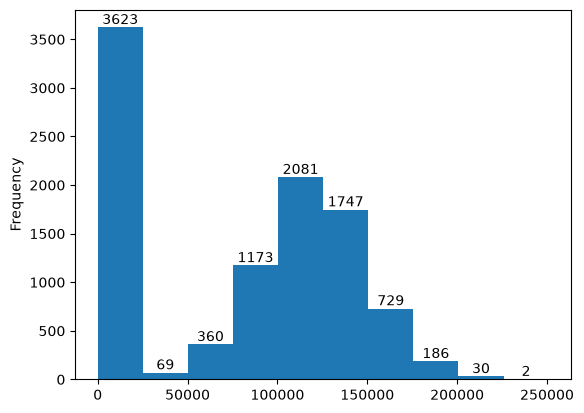

In [62]:
ax=df['Balance'].plot(kind='hist')
ax.bar_label(ax.containers[0])

[Text(0, 0, '987'),
 Text(0, 0, '968'),
 Text(0, 0, '1006'),
 Text(0, 0, '1027'),
 Text(0, 0, '1002'),
 Text(0, 0, '1027'),
 Text(0, 0, '1007'),
 Text(0, 0, '982'),
 Text(0, 0, '1009'),
 Text(0, 0, '985')]

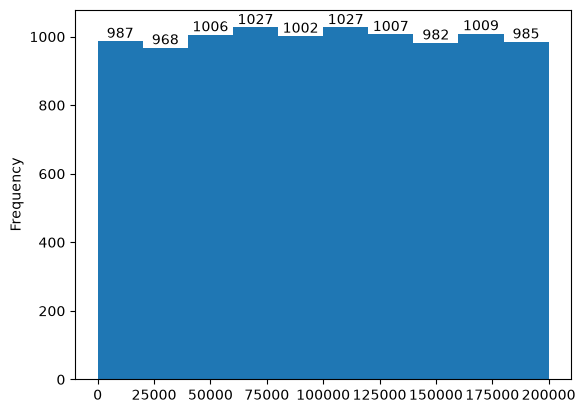

In [63]:
ax=df['EstimatedSalary'].plot(kind='hist')
ax.bar_label(ax.containers[0])

<Axes: xlabel='NumOfProducts'>

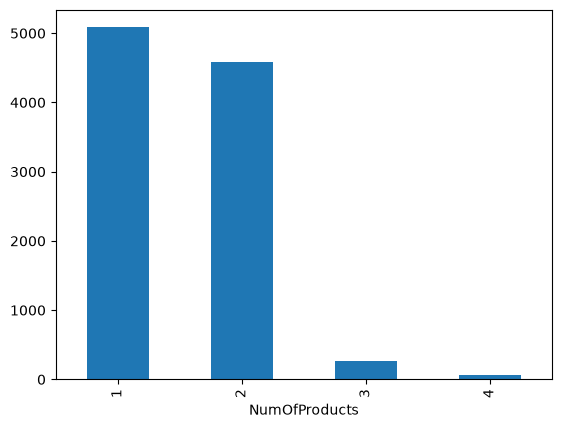

In [64]:
df['NumOfProducts'].value_counts().plot(kind='bar')

<Axes: xlabel='HasCrCard'>

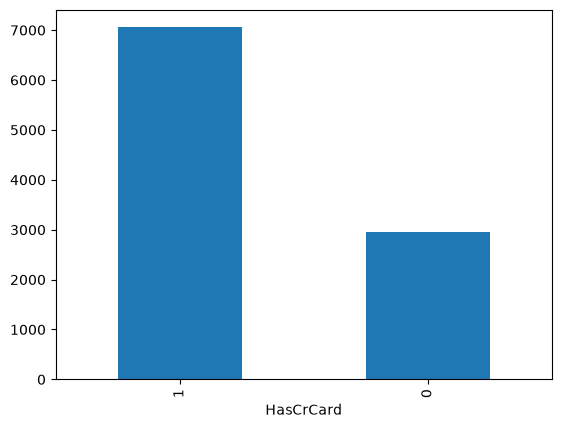

In [65]:
df['HasCrCard'].value_counts().plot(kind='bar')

<Axes: xlabel='IsActiveMember'>

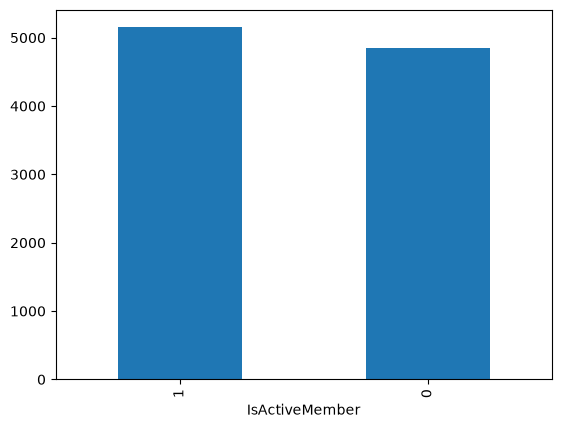

In [66]:
df['IsActiveMember'].value_counts().plot(kind='bar')

<Axes: >

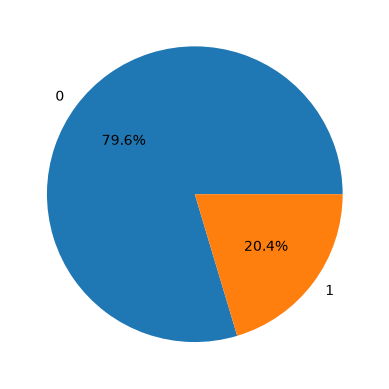

In [67]:
df['Exited'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [68]:
# Univariate

## Categorical col:
1.Geography : France>Germany>Spain
2.Gender : Male>Female
3.surname : 2932 unique values

## Numerical col:
1. Creditscore :
Distribution: Approximately symetric
Skewness: -0.07
Outliers: Present(lower)
Business Decision: Valid score(350-850) so didn't remove.

2. Age
max age between 30 and 40
distribution : right skewed  
no. of outlier present but they are between 60 to 75 , it is valid so i didn't remove
insight: As age increases no. of customer decreases

3. Tenure
most of customer has tenure between 1 to 9 . only 0,10 has less than tenure 
customer has taken maximum no. of 2 year tenure.
no utlier present

4. Balance
most of 3623 customers has balance 0 .
high no. of customer who has actual high balance between 1L to 1.5L .
it is running like series 

5. EstimatedSalary
approximately evenly distributed - all the customer has approx same number of count of salary

6. NumOfProducts and HasCrCard
product order of customer : 1>2>3>4 
maximum customer buy only 1 product at a time
out of 10k 7k+ customer has cr card

7.Active member and Exited
There is mostly active member and 2k+ customer exited out of 10k customers

SyntaxError: invalid decimal literal (1173843029.py, line 4)

In [ ]:
# | Number of Unique Values                          | Kya Karna Chahiye?                                             |
# | ------------------------------------------------ | -------------------------------------------------------------- |
# | 2–10                                             | Countplot / Pie Chart                                          |
# | 10–30                                            | Bar Chart                                                      |
# | 30–50                                            | Top N Bar Chart                                                |
# | >50 (High Cardinality)                           | `nunique()`, `value_counts().head()`, avoid full countplot     |
# | Almost all unique (IDs, Names, Emails, Surnames) | Skip visualization; report cardinality and data quality checks |

# | Skewness    | Interpretation          |
# | ----------- | ----------------------- |
# | -0.5 to 0.5 | Approximately Symmetric |
# | < -0.5      | Left Skewed             |
# | > 0.5       | Right Skewed            |

# Bivariate 

In [ ]:
# Numerical vs Numerical
1.CreditScore vs Age
2.CreditScore vs Balance
3.CreditScore vs EstimatedSalary
4.Age vs Balance
5.Age vs EstimatedSalary
6.Balance vs EstimatedSalary
7.Tenure vs Balance
8.NumOfProducts vs Balance

# Numerical vs Categorical
1.CreditScore vs Exited 
2.Age vs Exited 
3.Tenure vs Exited 
4.Balance vs Exited 
5.NumOfProducts vs Exited 
6.EstimatedSalary vs Exited 
7.CreditScore vs Gender 
8.Balance vs Geography 
9.Age vs Gender 

# Categorical vs Categorical
1.Gender vs Exited 
2.Geography vs Exited 
3.HasCrCard vs Exited 
4.IsActiveMember vs Exited 
5.Gender vs Geography 
6.Geography vs HasCrCard 

# Numerical vs Numerical

In [ ]:
# 1.CreditScore vs Age
df[['CreditScore', 'Age']].corr() 

In [ ]:
# Best for checking relationship between two features
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(numeric_only=True), annot=True ,fmt=".3f", cmap="coolwarm" )

In [ ]:
# Show visualization of two columns
sns.scatterplot(data=df ,x='CreditScore',y= 'Age' )
plt.title('Credit Score vs Age')
plt.show()

In [ ]:
sns.regplot(data=df ,x='CreditScore',y= 'Age' ,scatter_kws={'alpha':0.4}, line_kws={'color':'red'} )
plt.title('Credit Score vs Age')
plt.show()

In [ ]:
 # not Recommendable for cat vs num , check when you have very less value in column also used in cat vs num
sns.heatmap(pd.crosstab(df['CreditScore'],df['Age'],normalize='columns')*100, cmap='coolwarm')

# # Numerical vs Categorical

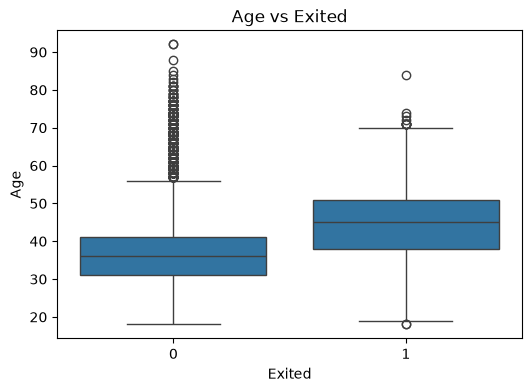

In [69]:
# 2.Age vs Exited
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Exited", y="Age")
plt.title("Age vs Exited")
plt.show()

In [70]:
| Step  | What to Check                       | Observation (Your Plot)                                      | Professional Insight                                                                                                            |
| ----- | ----------------------------------- | ------------------------------------------------------------ | ------------------------------------------------------------------------------------------------------------------------------- |
| **1** |   Median (Middle Line)              | Exited = 0 → ~35 years Exited = 1 → ~45 years                | Customers who exited have a  higher median age than customers who stayed. Older customers are more likely to churn.          |
| **2** |   Interquartile Range (IQR - Box)   | Exited = 0 → 31–40 years Exited = 1 →     38–50 years        | The middle 50% of exited customers are older than the middle 50% of retained customers.                                         |
| **3** |   Spread (Whiskers)                 | Exited = 1 has a slightly wider spread.                      | The age distribution of exited customers shows  slightly higher variability than stayed customer.                                                 |
| **4** |   Outliers (Circles)                | Both groups contain age outliers, especially at higher ages. | A few customers have unusually high ages, but they do not change the overall trend.                                             |
| **5** |   Overall Comparison                | The entire box for Exited = 1 is shifted upward.             | Customers who churn are generally  older than customers who remain. Age appears to be an important factor influencing churn. |

SyntaxError: invalid character '→' (U+2192) (1401561065.py, line 3)

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Age", hue="Exited", kde=True, bins=30)
plt.show()

In [ ]:
| Step  | What to Check                     | Observation (Your Plot)                                                                                                 | Professional Insight                                                                                                                      |
| ----- | --------------------------------- | ----------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------- |
| **1** | **Peak (Highest Bar / KDE Peak)** | Blue curve peaks around **35 years**, Orange peaks around **45 years**.                                                 | Most retained customers are around **35 years**, whereas most exited customers are around **45 years**.                                   |
| **2** | **Distribution (Shape)**          | Blue distribution is concentrated between **30–40 years**. Orange distribution is concentrated between **40–50 years**. | Younger customers are more likely to stay, while relatively older customers are more likely to churn.                                     |
| **3** | **Shift**                         | The orange curve is shifted to the **right** compared to the blue curve.                                                | Customers who exited tend to be older than customers who remained.                                                                        |
| **4** | **Overlap**                       | The two distributions overlap between approximately **35–50 years**.                                                    | Customers in this age range include both churned and retained customers, so age alone does not perfectly separate churn.                  |
| **5** | **Tail**                          | Both distributions extend toward higher ages (60–80+), but with fewer customers.                                        | Very old customers are relatively few in number in both groups.                                                                           |
| **6** | **Overall Conclusion**            | The orange distribution is generally located at higher ages than the blue distribution.                                 | **Age appears to be an important factor associated with customer churn. Older customers are more likely to exit than younger customers.** |

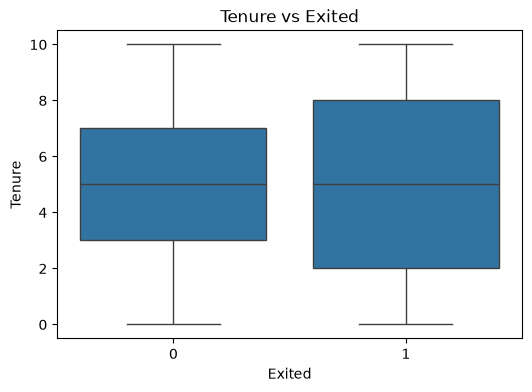

In [71]:
# 3.Tenure vs Exited
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Exited", y="Tenure")
plt.title("Tenure vs Exited")
plt.show()

In [72]:
# df.groupby('Exited')['Tenure'].agg('count')
pd.crosstab(df["Tenure"], df["Exited"]).sum() # Both gives same

Exited
0    7963
1    2037
dtype: int64

<Axes: xlabel='Tenure', ylabel='count'>

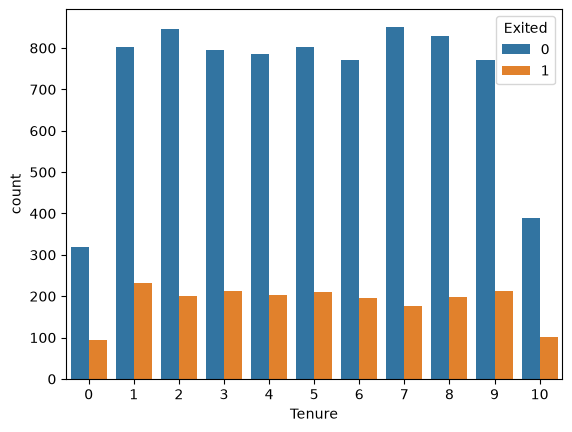

In [73]:
sns.countplot(data=df, x="Tenure", hue="Exited")

In [74]:
--> both customer who stayed vs exit have approx same year of tenure
--> customer with exit=0 have 3 to 7 year of tenure and rest of exit=1 have 2 to 8 yrs
--> there is no any outliers which affect the trend
--> overall the customer with exit=0 has maximum no. of tenure
--> Tenure alone does not appear to strongly differentiate customers who churn from those who remain.

SyntaxError: invalid syntax (3092107980.py, line 1)

In [ ]:
# 4.Balance vs Exited
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Exited", y="Balance")
plt.title("Exited vs Balance")
plt.show()

In [ ]:
df.groupby('Exited')['Balance'].agg('count')

In [ ]:
# 4.EstimatedSalary vs Exited
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Exited", y="EstimatedSalary")
plt.title("Exited vs EstimatedSalary")
plt.show()

In [ ]:
# 7.CreditScore vs Gender
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Gender", y="CreditScore")
plt.title("Gender vs CreditScore")
plt.show()

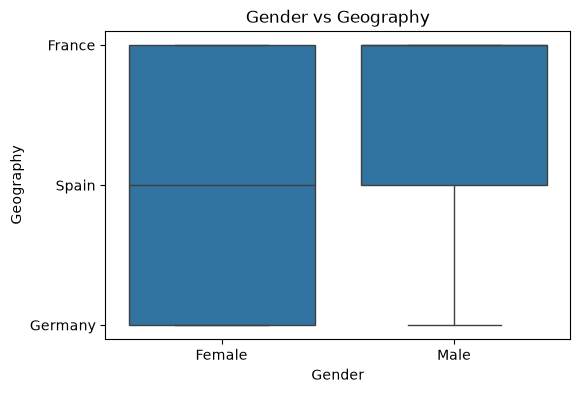

In [75]:
# 5.Gender vs Geography 
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Gender", y="Geography")
plt.title("Gender vs Geography")
plt.show()

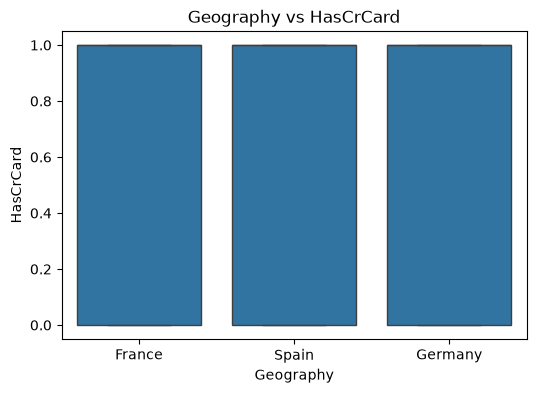

In [76]:
# 6.Geography vs HasCrCard 
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Geography", y="HasCrCard")
plt.title("Geography vs HasCrCard")
plt.show()

# # Categorical vs Categorical

In [77]:
# 1.Gender vs Exited 
# 2.Geography vs Exited 
# 3.HasCrCard vs Exited 
# 4.IsActiveMember vs Exited 
# 5.Gender vs Geography 
# 6.Geography vs HasCrCard 

<Axes: xlabel='Gender', ylabel='count'>

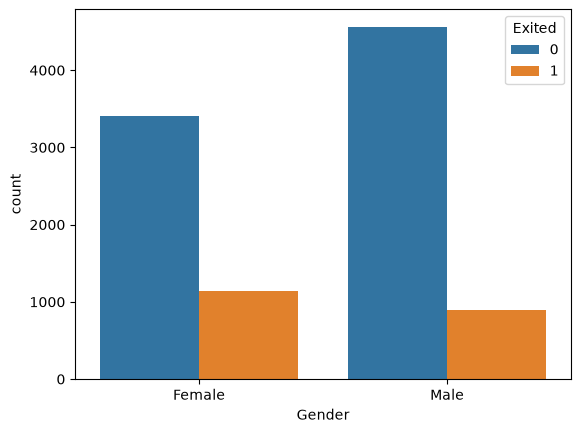

In [78]:
# 1.Gender vs Exited 
sns.countplot(df, x="Gender",hue='Exited')

<Axes: xlabel='Geography', ylabel='count'>

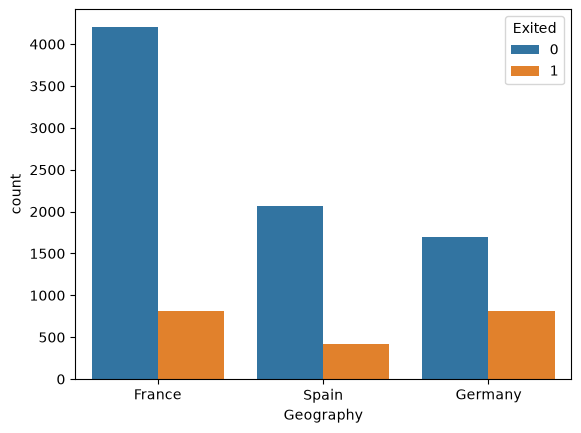

In [79]:
# 2.Geography vs Exited 
sns.countplot(df, x="Geography",hue='Exited')

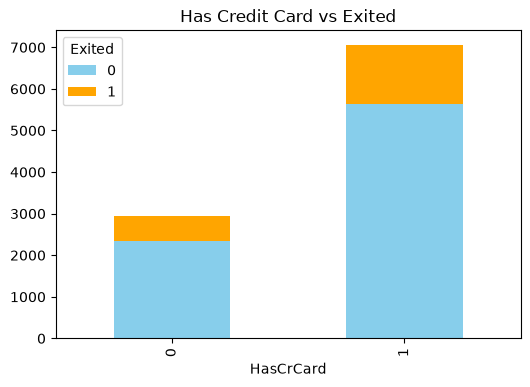

In [80]:
# 3.HasCrCard vs Exited 
ct = pd.crosstab(df['HasCrCard'], df['Exited'])

# Stacked Bar Plot
ct.plot(kind='bar',stacked=True,figsize=(6,4),color=['skyblue', 'orange'])

plt.title('Has Credit Card vs Exited')
plt.show()

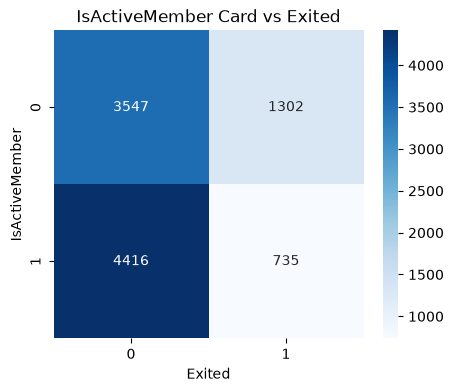

In [81]:
# 4.IsActiveMember vs Exited
ct = pd.crosstab(df['IsActiveMember'], df['Exited'])
plt.figure(figsize=(5,4))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')

plt.title('IsActiveMember Card vs Exited')
plt.xlabel('Exited')
plt.ylabel('IsActiveMember')
plt.show()

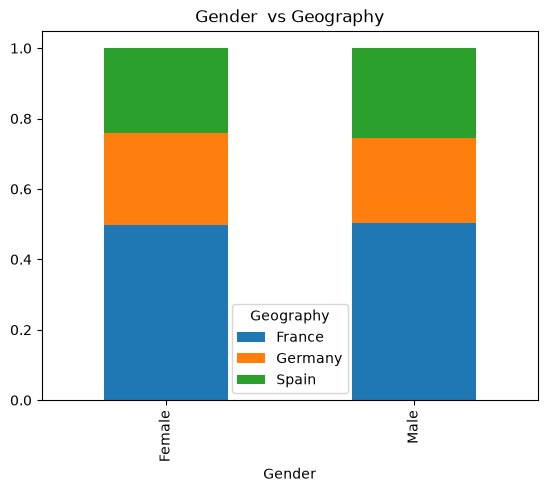

In [82]:
# 5.Gender vs Geography 
# Stacked abr
pd.crosstab(df['Gender'],df['Geography'],normalize='index').plot(kind='bar',stacked=True)
plt.title('Gender  vs Geography')
plt.show()

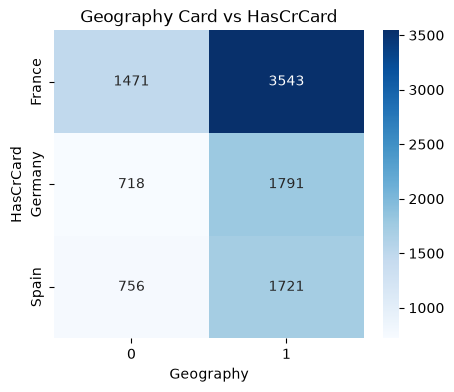

In [83]:
# 6.Geography vs HasCrCard  
ct = pd.crosstab(df['Geography'], df['HasCrCard'])
plt.figure(figsize=(5,4))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')

plt.title('Geography Card vs HasCrCard')
plt.xlabel('Geography')
plt.ylabel('HasCrCard')
plt.show()

In [84]:
Bivariate

# Numerical vs Numerical : Scatter Plot, Regression Plot,Heatmap,corr()
1.CreditScore vs Age
2.CreditScore vs Balance
3.CreditScore vs EstimatedSalary
--> There is no significant linear relationship between CreditScore and Age (r = 0.006).
--> no relationship

4.Age vs Balance
5.Age vs EstimatedSalary
--> no relationship

6.Balance vs EstimatedSalary
7.Tenure vs Balance
8.NumOfProducts vs Balance
--> There are no any relationship between numerical vs numerical

# Numerical vs Categorical : Box plot, Violin Plot, Bar Plot  
1.CreditScore vs Exited 
2.Age vs Exited 

for boxplot
| Step  | What to Check                       | Observation                                                  | Professional Insight                                                                                                            |
| ----- | ----------------------------------- | ------------------------------------------------------------ | ------------------------------------------------------------------------------------------------------------------------------- |
| **1** |   Median (Middle Line)              | Exited = 0 → ~35 years Exited = 1 → ~45 years                | Customers who exited have a  higher median age than customers who stayed. Older customers are more likely to churn.             |
| **2** |   Interquartile Range (IQR - Box)   | Exited = 0 → 31–40 years Exited = 1 →     38–50 years        | The middle 50% of exited customers are older than the middle 50% of retained customers.                                         |
| **3** |   Spread (Whiskers)                 | Exited = 1 has a slightly wider spread.                      | The age distribution of exited customers shows  slightly higher variability than stayed customer.                               |                   
| **4** |   Outliers (Circles)                | Both groups contain age outliers, especially at higher ages. | A few customers have unusually high ages, but they do not change the overall trend.                                             |
| **5** |   Overall Comparison                | The entire box for Exited = 1 is shifted upward.             | Customers who churn are generally  older than customers who remain. Age appears to be an important factor influencing churn.    |

--> there is  older age of customer more likely to churn than younger.
--> Age 40-50 are churning.
    
3.Tenure vs Exited 
--> both customer who stayed vs exit have approx same year of tenure
--> customer with exit=0 have 3 to 7 year of tenure and rest of exit=1 have 2 to 8 yrs
--> there is no any outliers which affect the trend
--> overall the customer with exit=0 has maximum no. of tenure
--> Tenure alone does not appear to strongly differentiate customers who churn from those who remain.
    
4.Balance vs Exited 

5.NumOfProducts vs Exited 
6.EstimatedSalary vs Exited 
7.CreditScore vs Gender 
8.Balance vs Geography 
9.Age vs Gender 

# Categorical vs Categorical : Countplot (Hue), Stacked Bar, Crosstab Heatmap
1.Gender vs Exited 
2.Geography vs Exited 
3.HasCrCard vs Exited 
4.IsActiveMember vs Exited 
5.Gender vs Geography 
6.Geography vs HasCrCard 

SyntaxError: invalid decimal literal (3607317180.py, line 4)

# Multivariate

In [85]:
# 1.Gender,Geography and Exited
# 2.Gender,NumOfProducts and Exited
# 3.Gender,Tenure and Exited
# 4.Gender,EstimatedSalary and Exited

[Text(0, 0, '460'),
 Text(0, 0, '448'),
 Text(0, 0, '231'),
 Text(0, 0, '350'),
 Text(0, 0, '366'),
 Text(0, 0, '182')]

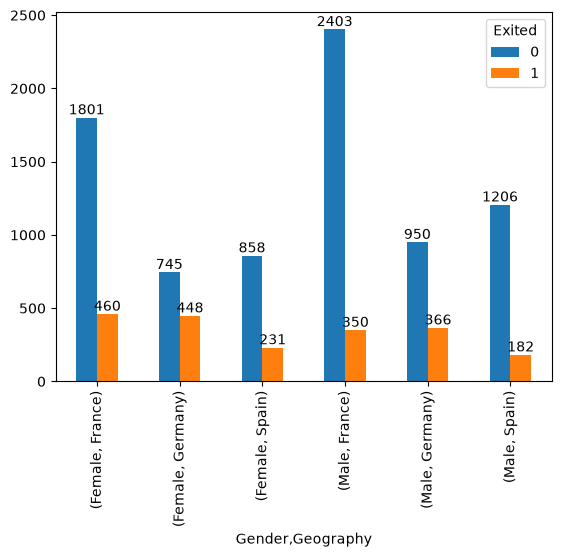

In [86]:
# 1.Gender,Geography and Exited
ax=df.groupby(["Gender", "Geography" , "Exited"])["Exited"].count().unstack().plot.bar()
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

<Axes: xlabel='Gender,NumOfProducts'>

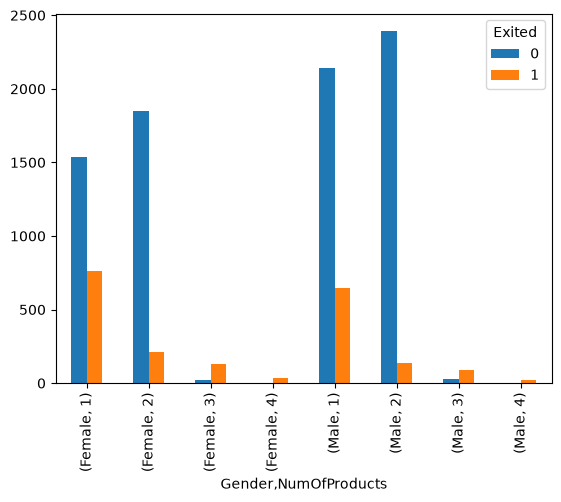

In [87]:
# 2.Gender,NumOfProducts and Exited
df.groupby(["Gender", "NumOfProducts" , "Exited"])["Exited"].count().unstack().plot.bar()

<Axes: xlabel='Gender,Tenure'>

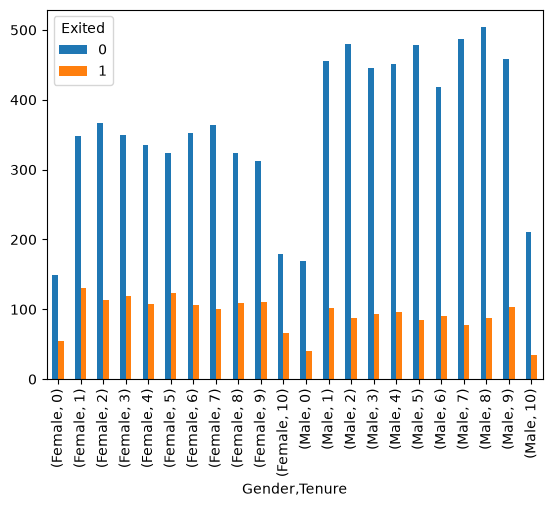

In [88]:
# 3.Gender,Tenure and Exited
df.groupby(["Gender", "Tenure" , "Exited"])["Exited"].count().unstack().plot.bar()

In [89]:
# 1.Gender,Geography and Exited
male customer from Germany exited slightly higher than male from Frnace.
male customer from france stayed in high number.
very few number of male customer from france exited  .
    
Female customer from france stayed mostly.
Female customer from france exited mostly.
very few no. of Female customer from spain exited .

# 2.Gender,NumOfProducts and Exited
There are male and female both with 1 and 2 products staying.
There are male and female both with 1 products exited mostly.
There are male and female both with 4 products exited mostly.

# 3.Gender,Tenure and Exited
male and female with 1 to 9 years tenure staying amd same for exited
    

SyntaxError: invalid syntax (1881824871.py, line 2)

In [91]:
export = df.to_csv("cleaned_data.csv")